In [1]:
# cell 1 — imports and GradCAM implementation from scratch
# We implement GradCAM manually rather than using a library
# Reason: demonstrates understanding of the mechanism,
# and pytorch-grad-cam requires specific hook patterns
# that differ across model architectures

from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from copy import deepcopy

PROJECT_ROOT  = Path('..')
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'coatings_manifest.csv'
MODELS_DIR    = PROJECT_ROOT / 'models'
REPORTS_DIR   = PROJECT_ROOT / 'reports'

df = pd.read_csv(MANIFEST_PATH)
df['abs_path'] = df['path'].apply(lambda p: PROJECT_ROOT.resolve() / p)

LABEL_CLASSES = sorted(df['label'].unique().tolist())
LABEL_TO_IDX  = {lbl: i for i, lbl in enumerate(LABEL_CLASSES)}
IDX_TO_LABEL  = {i: lbl for lbl, i in LABEL_TO_IDX.items()}
NUM_CLASSES   = len(LABEL_CLASSES)
DEVICE        = torch.device('cpu')

IMAGE_SIZE    = 224
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

class GradCAM:
    '''
    Gradient-weighted Class Activation Mapping (Selvaraju et al., 2017)
    Target layer: last convolutional block before global average pooling
    For EfficientNet-B0: model.features[-1] (the final Conv2d block)
    '''
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()

        # Global average pool the gradients over spatial dimensions
        weights      = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        cam          = (weights * self.activations).sum(dim=1).squeeze()  # [H, W]
        cam          = torch.relu(cam)

        # Normalise to [0, 1]
        cam          = cam.numpy()
        cam          = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        # Resize to input image size
        cam_resized  = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))
        return cam_resized, class_idx, torch.softmax(output, dim=1)[0, class_idx].item()

print('GradCAM class ready.')
print(f'Classes: {LABEL_CLASSES}')

GradCAM class ready.
Classes: ['adhesion_loss', 'blistering', 'chalking', 'corrosion', 'crack_paint', 'fading', 'sagging']


In [2]:
# cell 2 — load the best fold checkpoint (pick fold with highest val_acc)
# Fine-tuned checkpoints are in models/efficientnet_b0_fold{n}_finetuned.pth

def build_model(num_classes):
    model = models.efficientnet_b0(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(model.classifier[1].in_features, num_classes)
    )
    return model

# Load the best fold — fold 5 had 100% val acc after fine-tuning
BEST_CKPT = MODELS_DIR / 'efficientnet_b0_fold5_finetuned.pth'

ckpt  = torch.load(BEST_CKPT, map_location=DEVICE)
model = build_model(NUM_CLASSES)
model.load_state_dict(ckpt['state_dict'])
model.eval()

# Target layer: last block of EfficientNet features (features[8] = final Conv + BN + SiLU)
target_layer = model.features[8]
gradcam      = GradCAM(model, target_layer)

print(f'Loaded: {BEST_CKPT.name}')
print(f'Val acc at save: {ckpt["val_acc"]:.3f}')
print(f'Target layer: {target_layer.__class__.__name__}')

Loaded: efficientnet_b0_fold5_finetuned.pth
Val acc at save: 1.000
Target layer: Conv2dNormActivation


In [3]:
# cell 3 — image preprocessing for inference

def preprocess(img_path: Path):
    '''Load, resize, normalise — returns (tensor, original_rgb_image)'''
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize preserving aspect ratio, then pad
    h, w    = img_rgb.shape[:2]
    scale   = IMAGE_SIZE / max(h, w)
    nh, nw  = int(h * scale), int(w * scale)
    resized = cv2.resize(img_rgb, (nw, nh))

    canvas  = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
    y_off   = (IMAGE_SIZE - nh) // 2
    x_off   = (IMAGE_SIZE - nw) // 2
    canvas[y_off:y_off+nh, x_off:x_off+nw] = resized

    norm    = (canvas.astype(np.float32) / 255.0 - IMAGENET_MEAN) / IMAGENET_STD
    tensor  = torch.tensor(norm.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0)
    return tensor, canvas

def overlay_cam(img_rgb, cam, alpha=0.45):
    '''Overlay GradCAM heatmap on image'''
    heatmap = cm.jet(cam)[:, :, :3]               # jet colormap → RGB
    heatmap = (heatmap * 255).astype(np.uint8)
    overlay = (alpha * heatmap + (1 - alpha) * img_rgb).astype(np.uint8)
    return overlay

print('Preprocessing helpers ready.')

Preprocessing helpers ready.


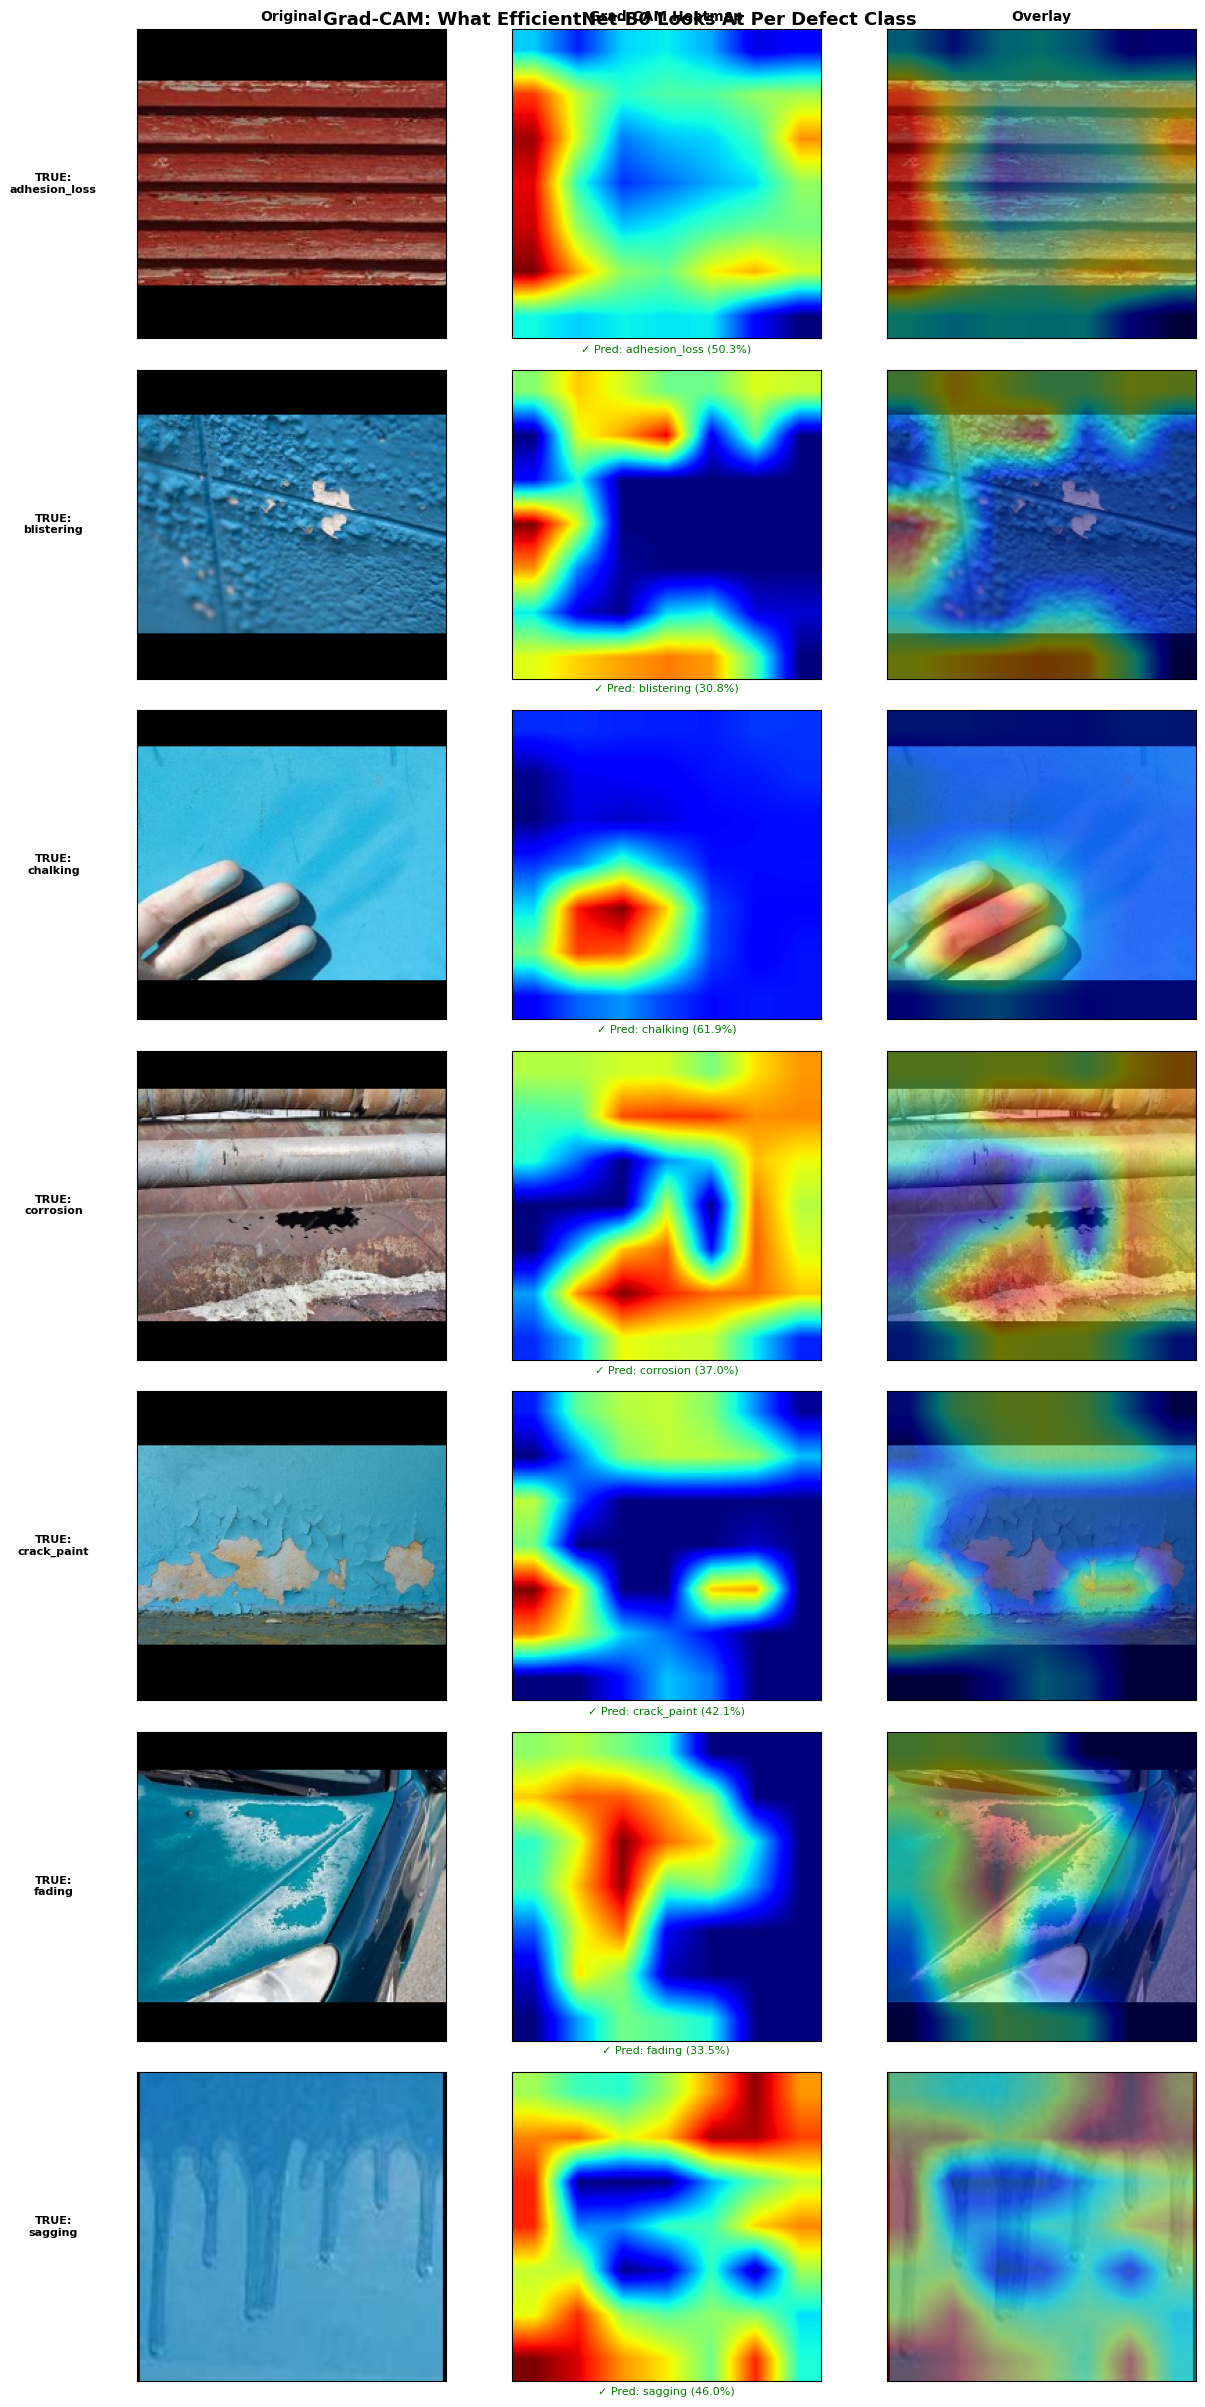

Saved → reports/gradcam_per_class.png


In [4]:
# cell 4 — run GradCAM on one representative image per defect class
# Select the first image from each class in the manifest

fig, axes = plt.subplots(NUM_CLASSES, 3,
                          figsize=(13, NUM_CLASSES * 3.5))
fig.suptitle('Grad-CAM: What EfficientNet-B0 Looks At Per Defect Class',
             fontsize=13, fontweight='bold')

col_titles = ['Original', 'Grad-CAM Heatmap', 'Overlay']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=10, fontweight='bold')

for row, label in enumerate(LABEL_CLASSES):
    img_path = df[df['label'] == label].iloc[0]['abs_path']
    tensor, img_display = preprocess(img_path)

    cam, pred_idx, confidence = gradcam.generate(tensor)
    pred_label = IDX_TO_LABEL[pred_idx]
    overlay    = overlay_cam(img_display, cam)
    heatmap    = (cm.jet(cam)[:, :, :3] * 255).astype(np.uint8)

    # Column 0: original
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_ylabel(f'TRUE:\n{label}', fontsize=8, fontweight='bold',
                             rotation=0, labelpad=60, va='center')

    # Column 1: heatmap only
    axes[row, 1].imshow(heatmap)
    correct   = '✓' if pred_label == label else '✗'
    axes[row, 1].set_xlabel(f'{correct} Pred: {pred_label} ({confidence:.1%})',
                              fontsize=8,
                              color='green' if pred_label == label else 'red')

    # Column 2: overlay
    axes[row, 2].imshow(overlay)

    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'gradcam_per_class.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → reports/gradcam_per_class.png')

C:\Users\gaura\AppData\Local\Temp\ipykernel_14176\2903350490.py:11: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(IMAGE_SIZE, IMAGE_SIZE,


Total misclassified images: 2
  blistering      → predicted as corrosion       (27.5%)
  fading          → predicted as sagging         (35.3%)


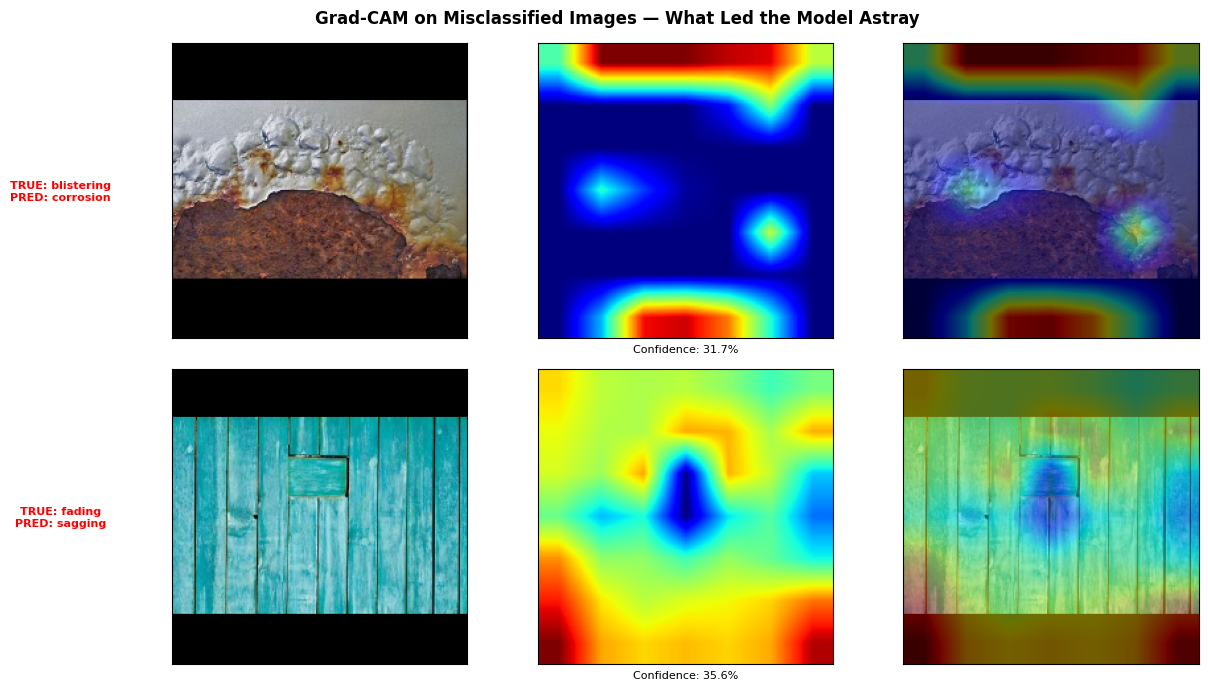

Saved → reports/gradcam_failures.png


In [5]:
# cell 5 — GradCAM on failure cases
# For each class, find an image that was misclassified by the model
# and show what the model attended to — this reveals WHY it failed

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

val_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE),
    A.PadIfNeeded(IMAGE_SIZE, IMAGE_SIZE,
                  border_mode=cv2.BORDER_CONSTANT, value=0),
    A.Normalize(mean=IMAGENET_MEAN.tolist(), std=IMAGENET_STD.tolist()),
    ToTensorV2(),
])

model.eval()
failures = []

for _, row in df.iterrows():
    img = cv2.imread(str(row['abs_path']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    tensor_aug = val_transforms(image=img)['image'].unsqueeze(0)

    with torch.no_grad():
        out      = model(tensor_aug)
        pred_idx = out.argmax(1).item()
        conf     = torch.softmax(out, dim=1)[0, pred_idx].item()

    true_idx = LABEL_TO_IDX[row['label']]
    if pred_idx != true_idx:
        failures.append({
            'path':       row['abs_path'],
            'true_label': row['label'],
            'pred_label': IDX_TO_LABEL[pred_idx],
            'confidence': conf,
        })

print(f'Total misclassified images: {len(failures)}')
for f in failures:
    print(f'  {f["true_label"]:<15s} → predicted as {f["pred_label"]:<15s} ({f["confidence"]:.1%})')

if failures:
    n_show  = min(len(failures), 4)
    fig, axes = plt.subplots(n_show, 3, figsize=(13, n_show * 3.5))
    if n_show == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle('Grad-CAM on Misclassified Images — What Led the Model Astray',
                 fontsize=12, fontweight='bold')

    for row_idx, failure in enumerate(failures[:n_show]):
        tensor, img_display = preprocess(failure['path'])
        cam, pred_idx, conf = gradcam.generate(tensor)
        overlay             = overlay_cam(img_display, cam)
        heatmap             = (cm.jet(cam)[:, :, :3] * 255).astype(np.uint8)

        axes[row_idx, 0].imshow(img_display)
        axes[row_idx, 0].set_ylabel(
            f'TRUE: {failure["true_label"]}\nPRED: {failure["pred_label"]}',
            fontsize=8, fontweight='bold', rotation=0, labelpad=80, va='center',
            color='red')
        axes[row_idx, 1].imshow(heatmap)
        axes[row_idx, 1].set_xlabel(f'Confidence: {conf:.1%}', fontsize=8)
        axes[row_idx, 2].imshow(overlay)

        for ax in axes[row_idx]:
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'gradcam_failures.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved → reports/gradcam_failures.png')
else:
    print('No misclassifications found on this fold checkpoint.')